In [2]:
import os
import torch
os.environ["TORCH"]=torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

#fun for visualn

%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(G,color):
  plt.figure(figsize=(7,7))
  plt.xticks([])
  plt.yticks([])
  pos = nx.spring_layout(G, seed=2)
  nx.draw_networkx(G,pos=pos,with_labels=False,node_color=color,cmap="Set2")
  plt.show

def visualize_embedding(h,color,epoch = None,loss = None):
  plt.figure(figsize=(7,7))
  plt.xticks([])
  plt.yticks([])
  h = h.detach().cpu().numpy()
  plt.scatter(h[:,0],h[:,1],s=140,c=color,cmap="Set2")
  if epoch is not None and loss is not None:
    plt.xlabel(f"Epoch:{epoch}, loss:{loss.item():.4f}", fontsize=16)
  plt.show()

2.10.0+cpu
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#Graph Neural Network from basics


 Graph Neural Networks (GNNs) are Deep Learning models
 specially designed for graph structured data.

 A graph contains:
 1. Nodes  -> objects/entities
 2. Edges  -> connections between nodes

Examples of graph data: Social Networks, Road Networks, Molecules, Web Pages

Main Idea of GNN:
Each node learns information from its neighboring nodes. This process is called Message Passing.

Message Passing Equation:
$$\mathbf{h}_v^{(k)} =
\text{UPDATE}^{(k)}
\left(
\mathbf{h}_v^{(k-1)},
\text{AGGREGATE}^{(k)}
\left(
\left\{
\mathbf{h}_u^{(k-1)} :
u \in \mathcal{N}(v)
\right\}
\right)
\right)
$$

 Simple Meaning:
A node updates its information using neighbor information.

PyTorch Geometric (PyG):
PyG is a library built on top of PyTorch
used for implementing Graph Neural Networks easily.

Dataset Used:
Zachary's Karate Club Network
 - 34 nodes (club members)
 - edges represent connections/friendships

 Goal:
 Detect communities/groups inside the network.

In [3]:
from torch_geometric.datasets import KarateClub
dataset = KarateClub()
print("dataset:", dataset)
print("Properties of the graph")
print("number of graph:", len(dataset))
print("number of features:", dataset.num_features)
print("number of classes:", dataset.num_classes)


dataset: KarateClub()
Properties of the graph
number of graph: 1
number of features: 34
number of classes: 4


In [4]:
data = dataset[0]
print(data.edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

In [5]:
data = dataset[0]  # Get the first graph object.
print(data)
# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True


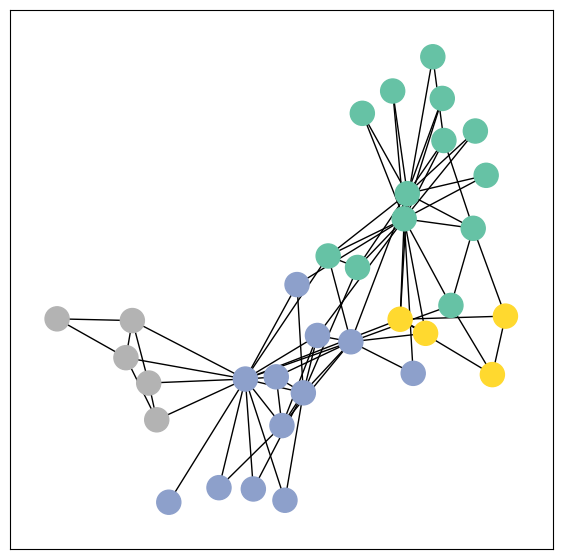

In [6]:
from torch_geometric.utils import to_networkx
G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

In [7]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
  def __init__(self):
    super().__init__()
    torch.manual_seed(1234)
    self.conv1=GCNConv(dataset.num_features,4)
    self.conv2=GCNConv(4,4)
    self.conv3=GCNConv(4,2)
    self.classifier = Linear(2,dataset.num_classes)

  def forward(self,x,edge_index):
    h=self.conv1(x,edge_index)
    h = h.relu()

    h=self.conv2(h,edge_index)
    h = h.relu()

    h=self.conv3(h,edge_index)
    h = h.relu()

    out = self.classifier(h)
    return out, h
model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


Embedding shape: [34, 2]


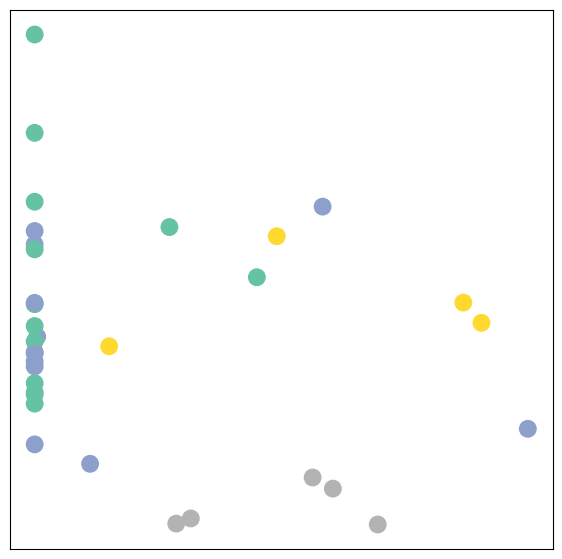

In [8]:
model = GCN()
_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')
visualize_embedding(h, color=data.y)

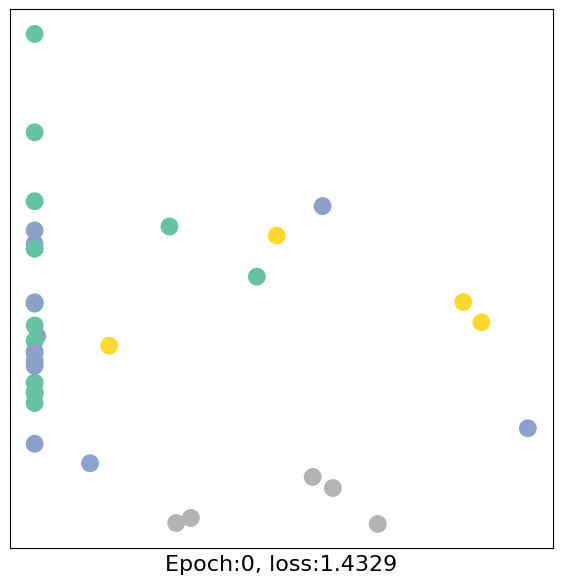

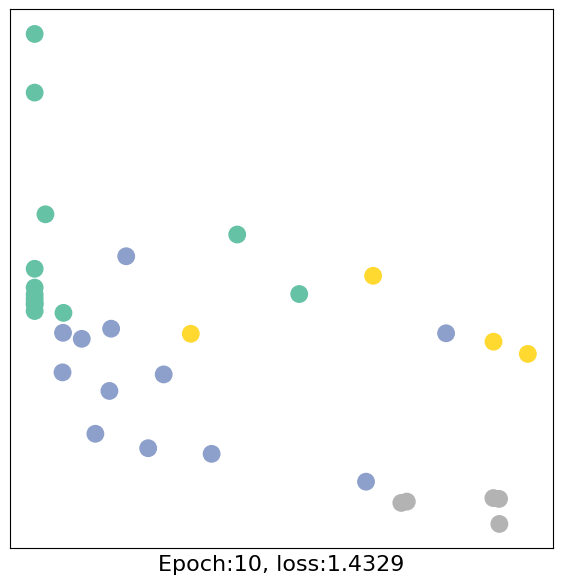

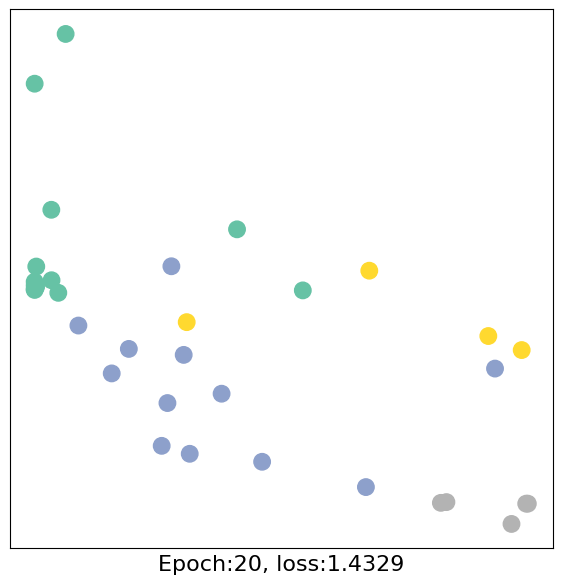

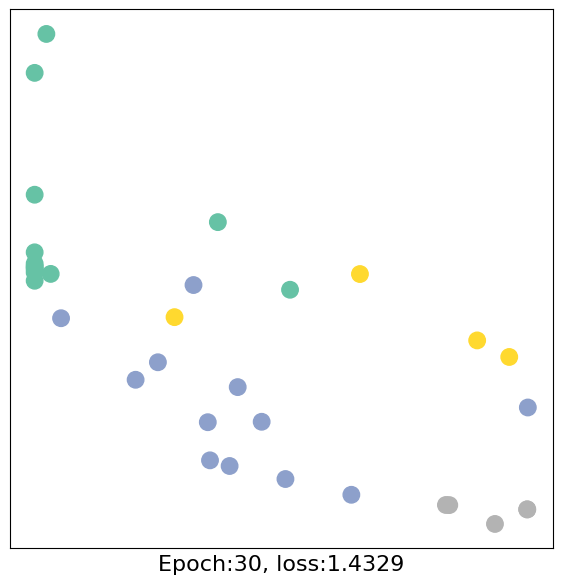

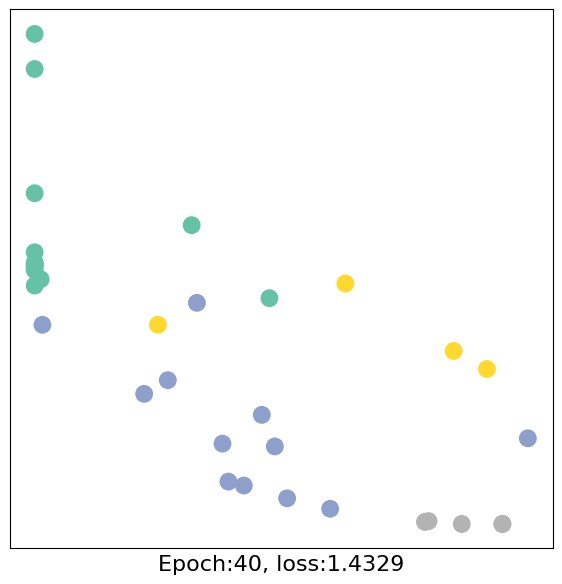

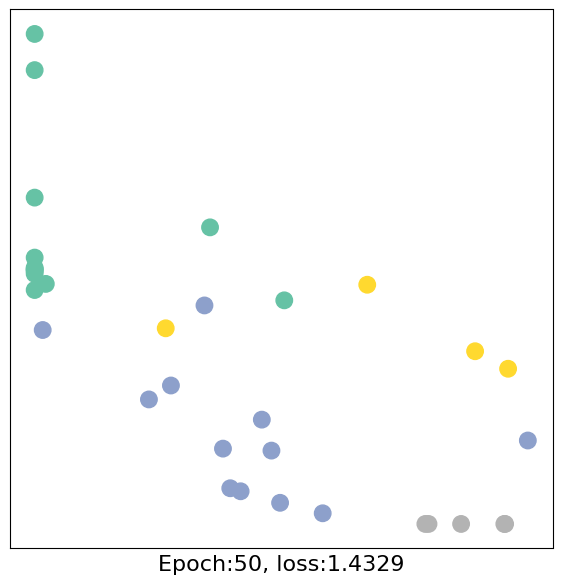

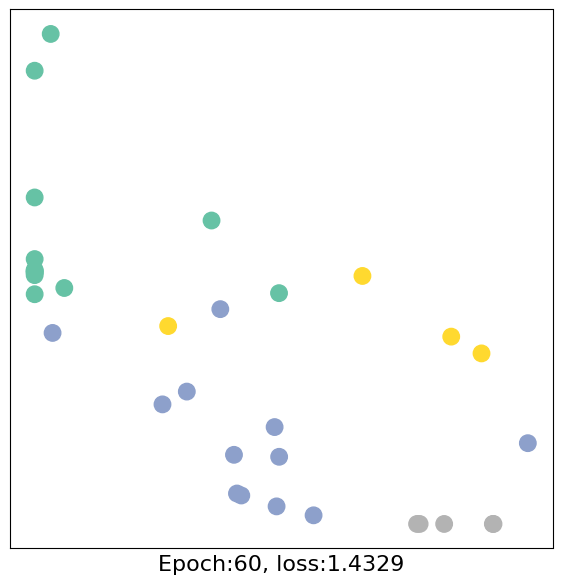

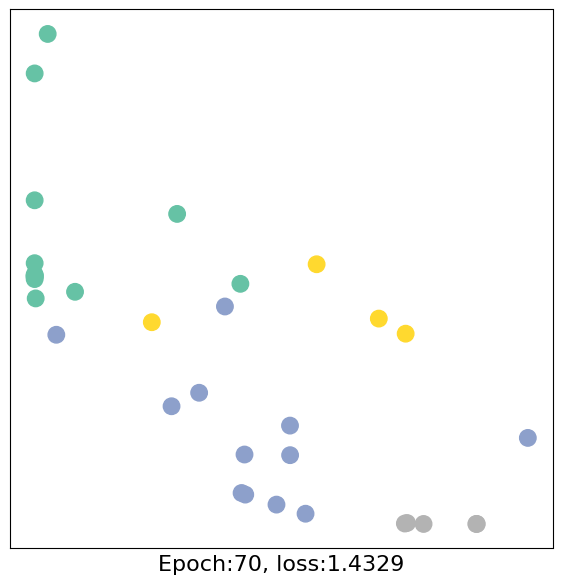

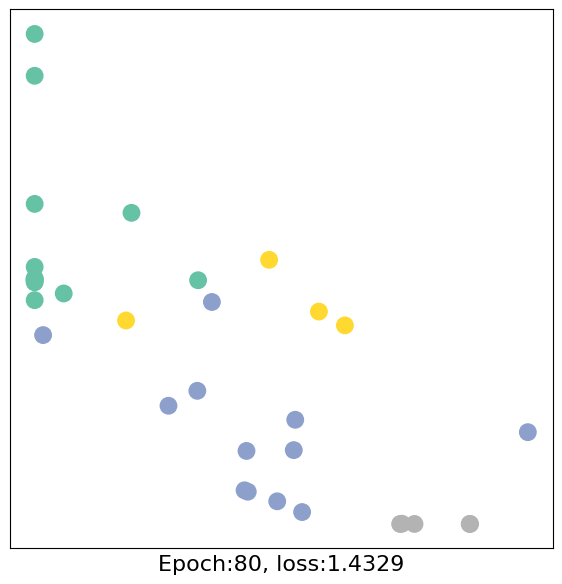

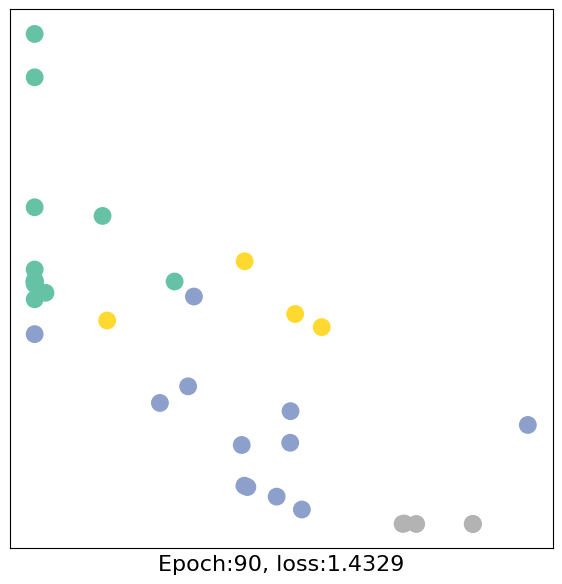

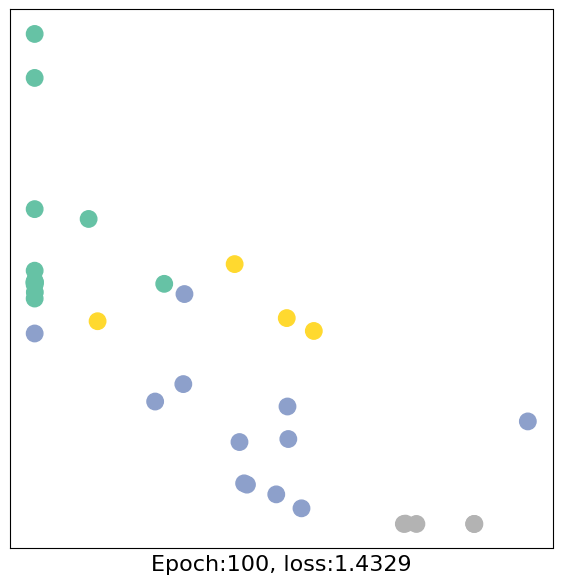

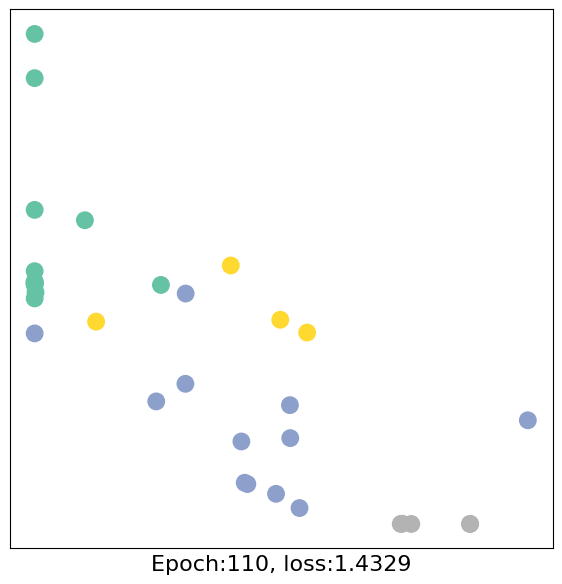

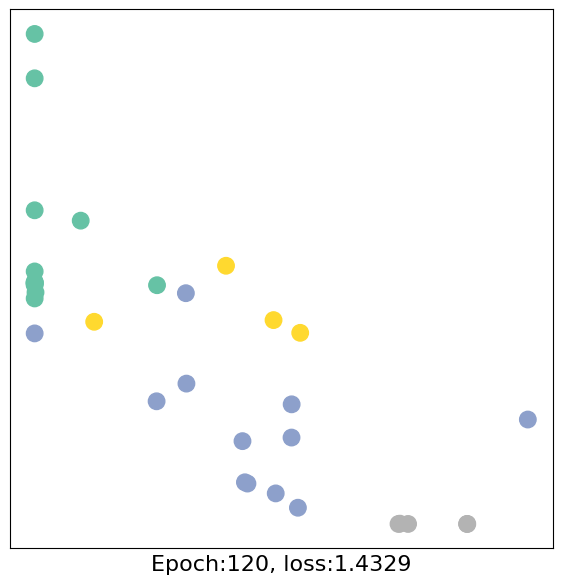

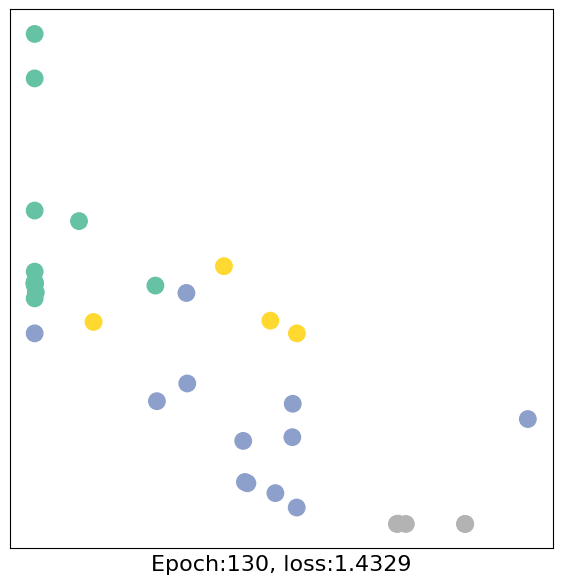

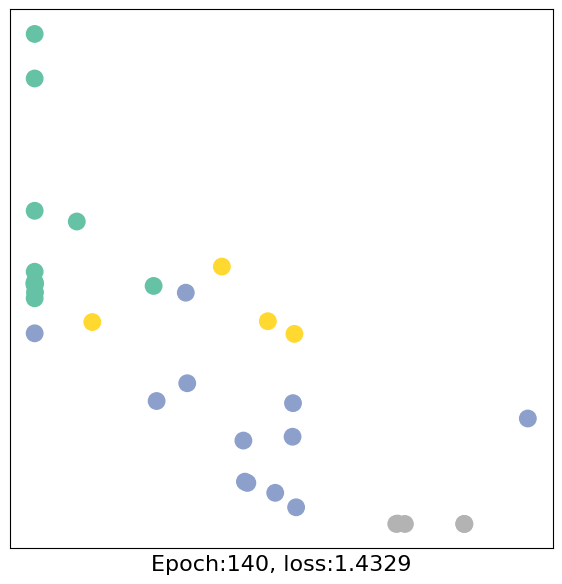

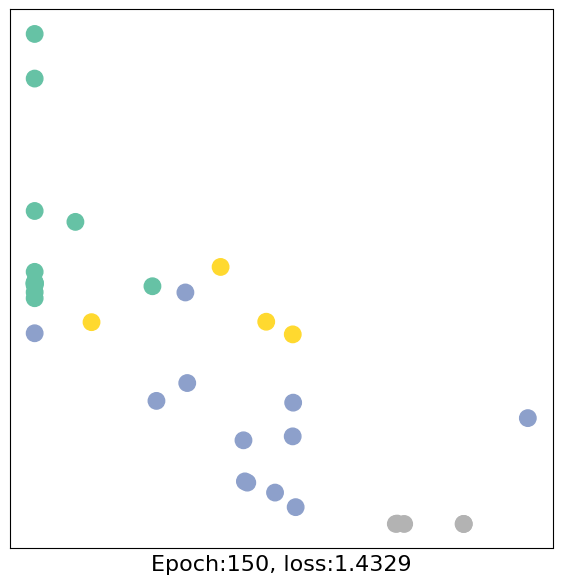

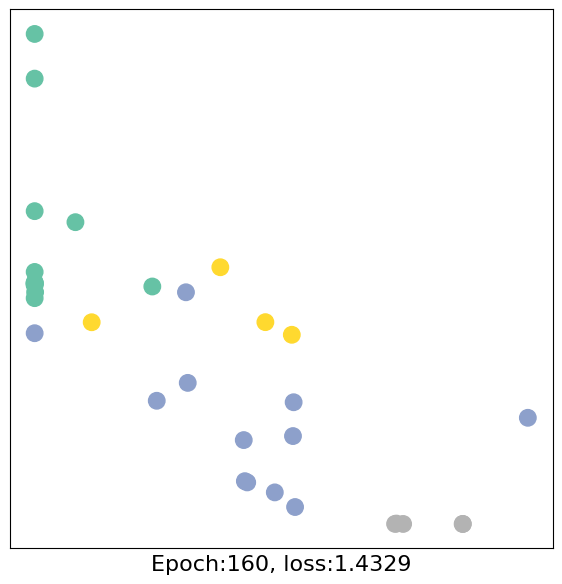

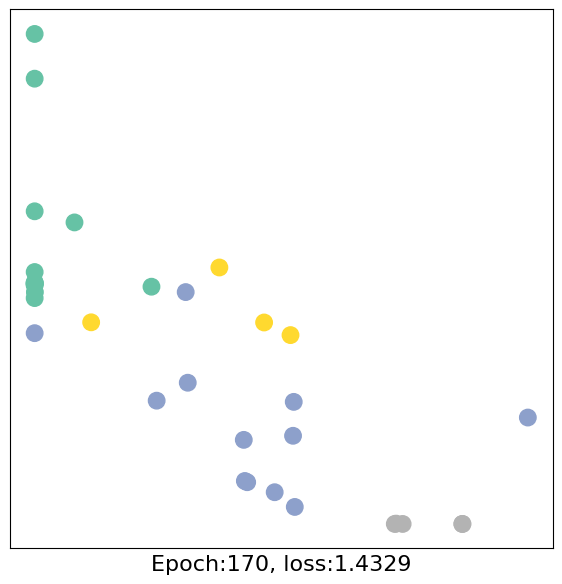

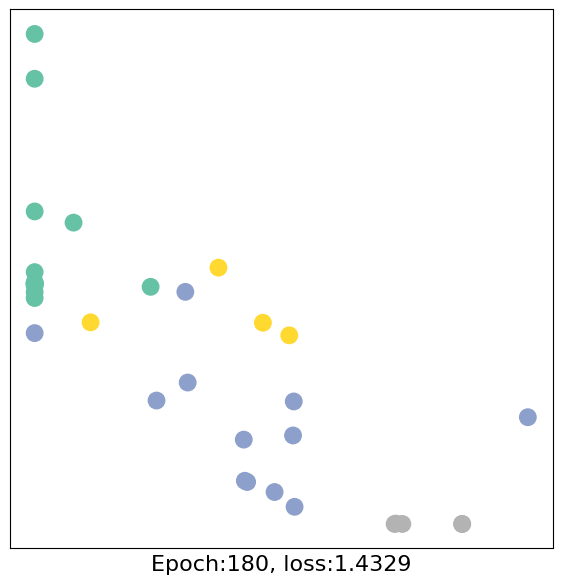

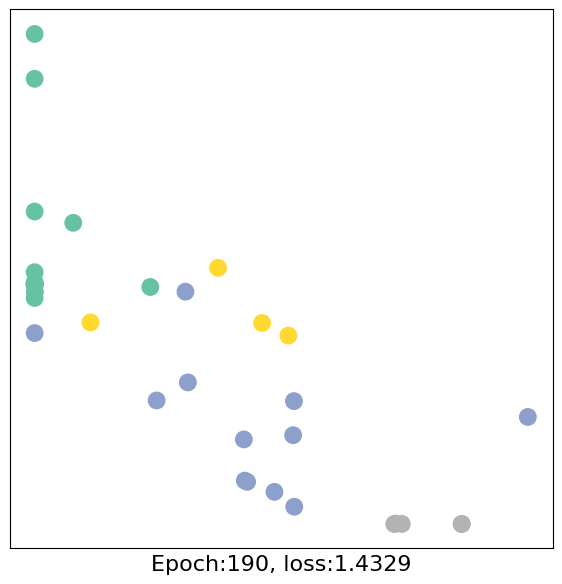

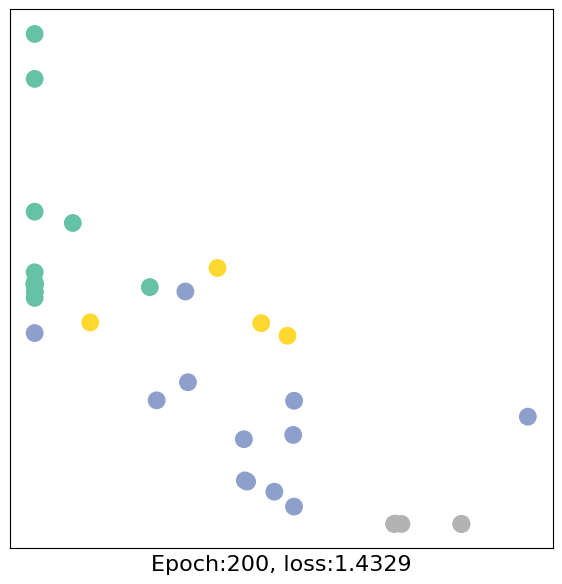

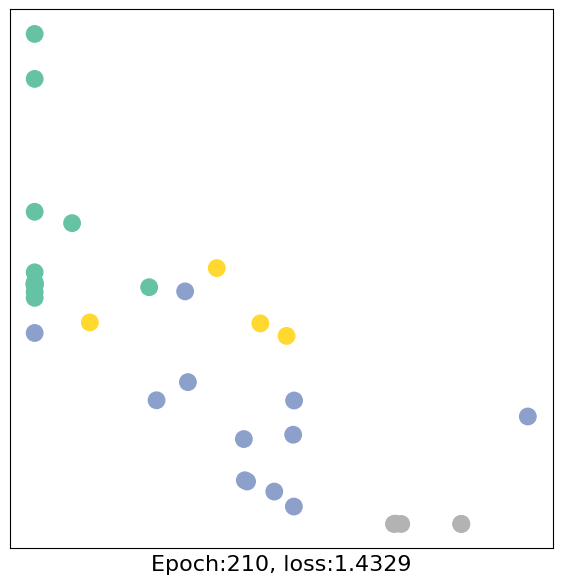

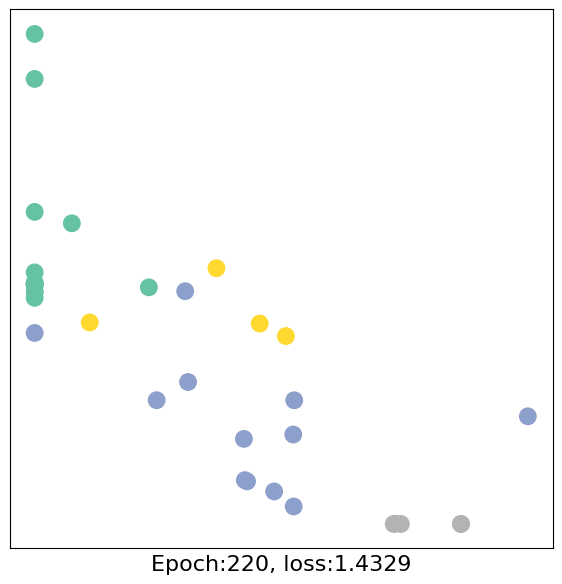

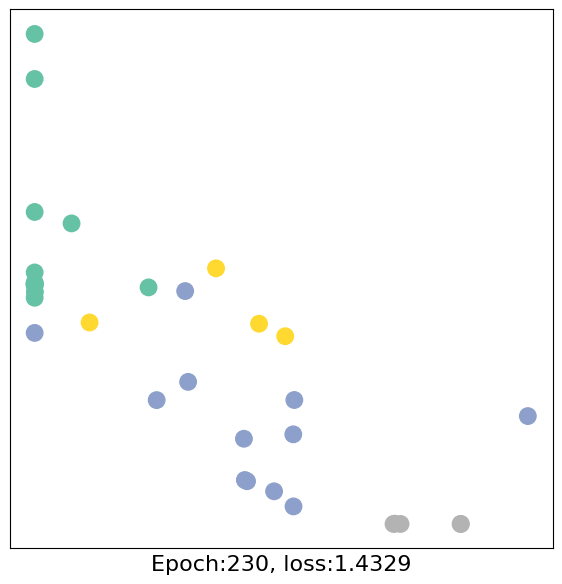

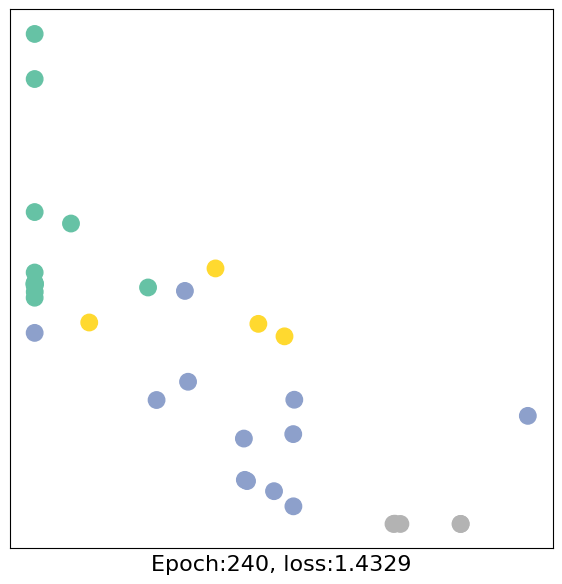

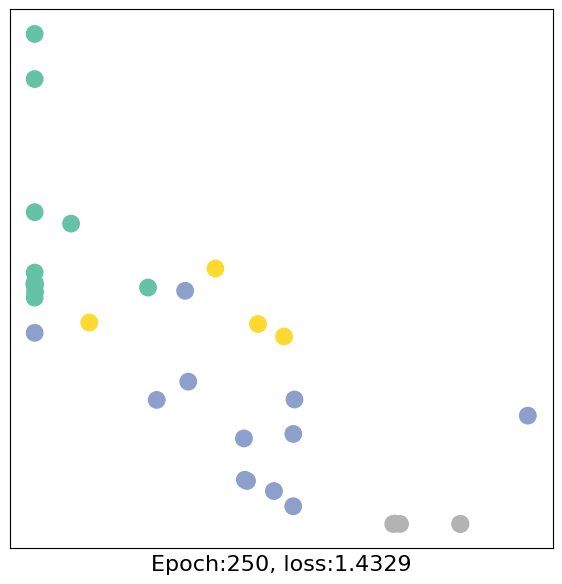

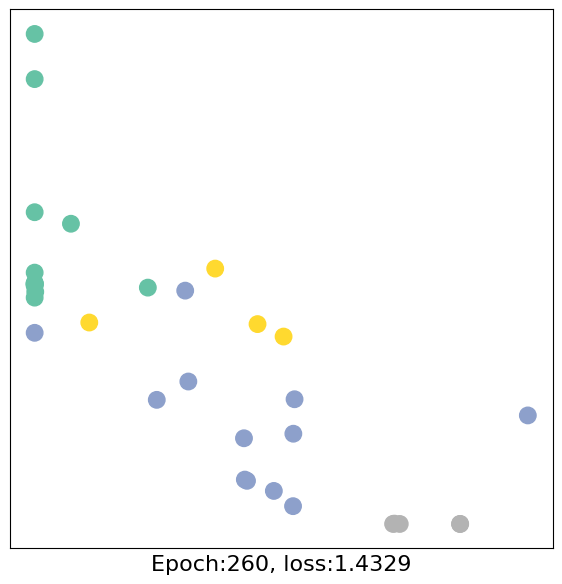

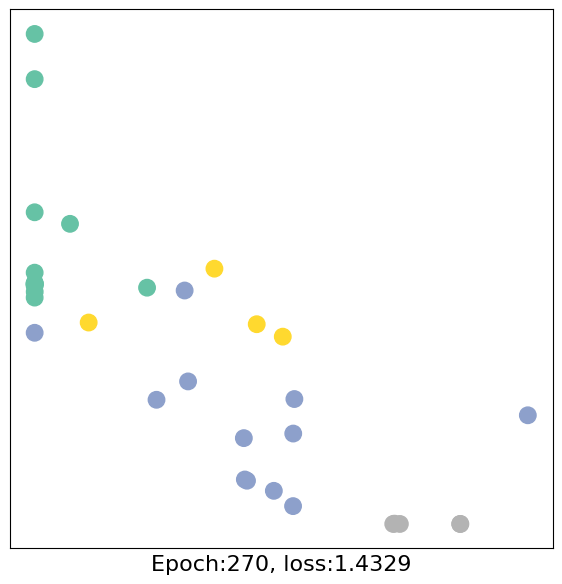

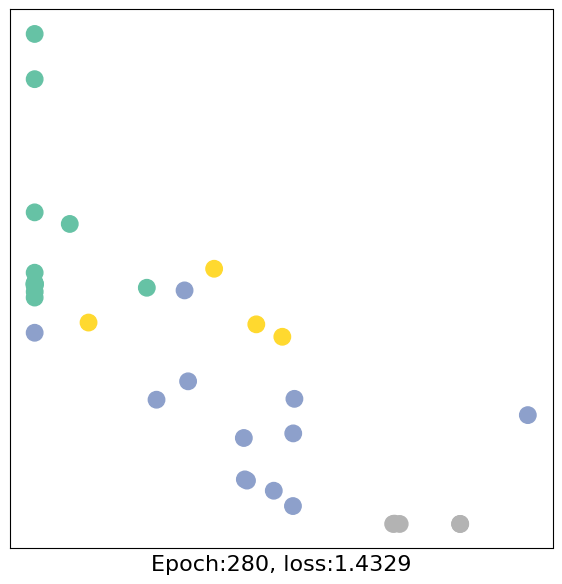

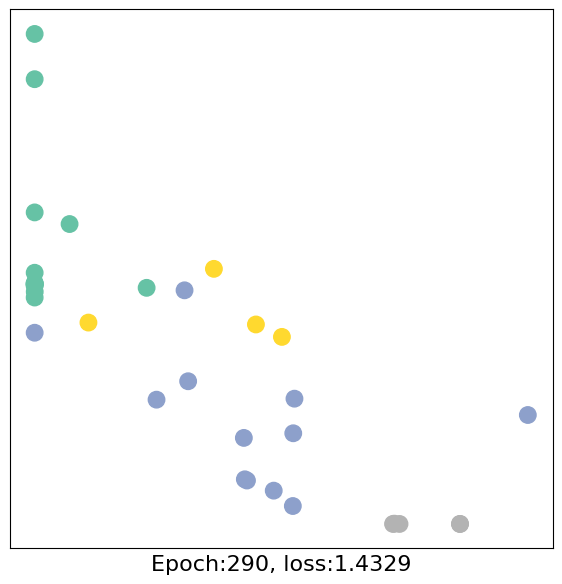

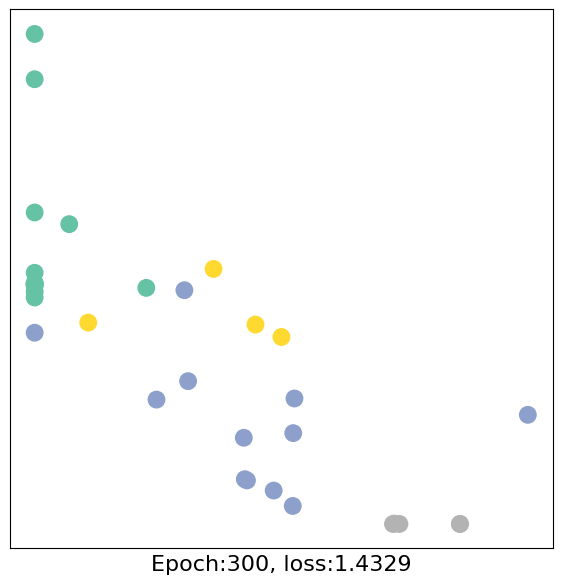

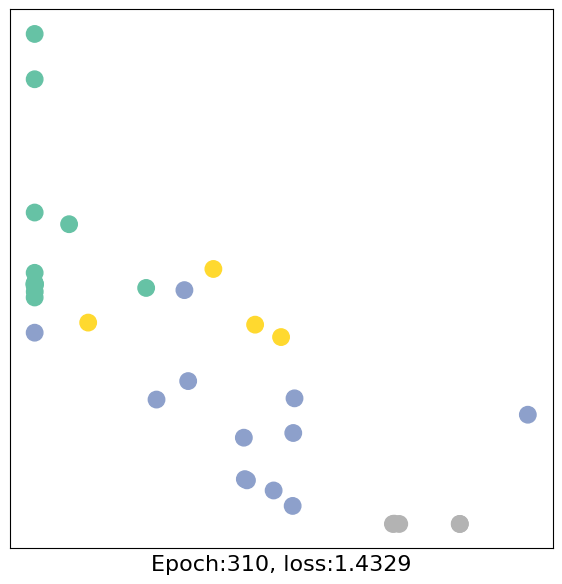

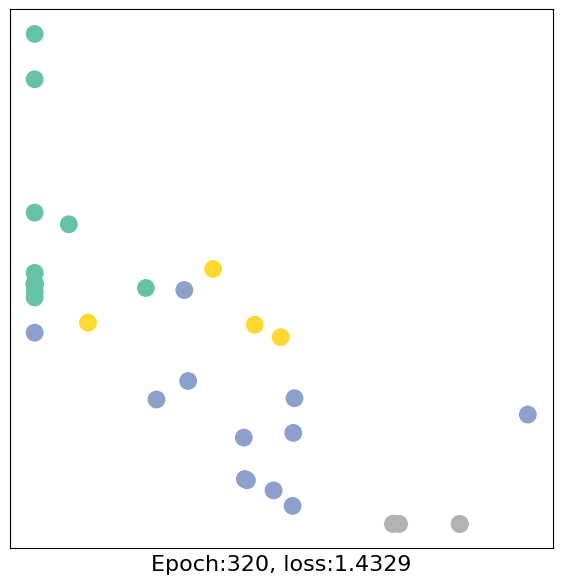

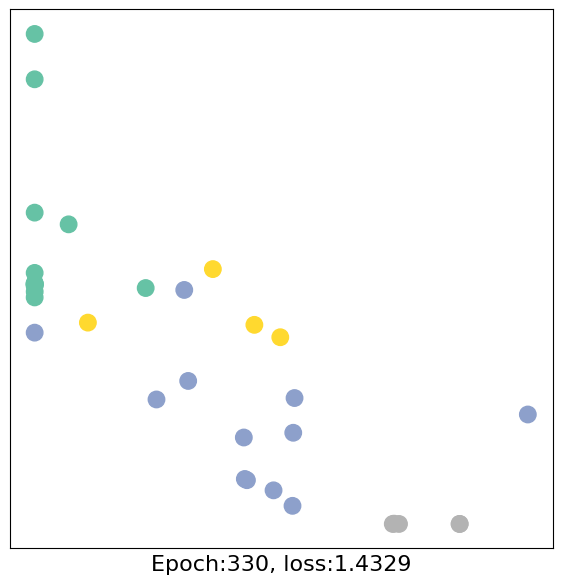

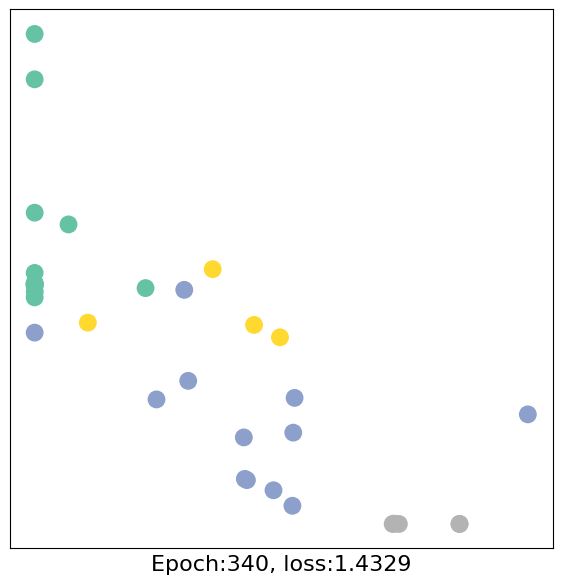

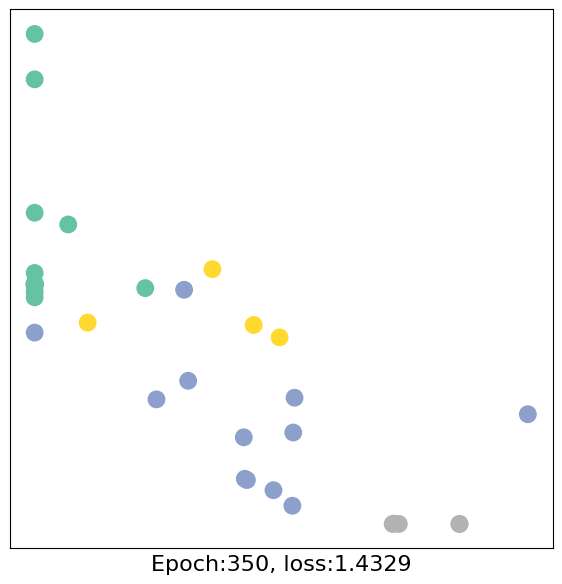

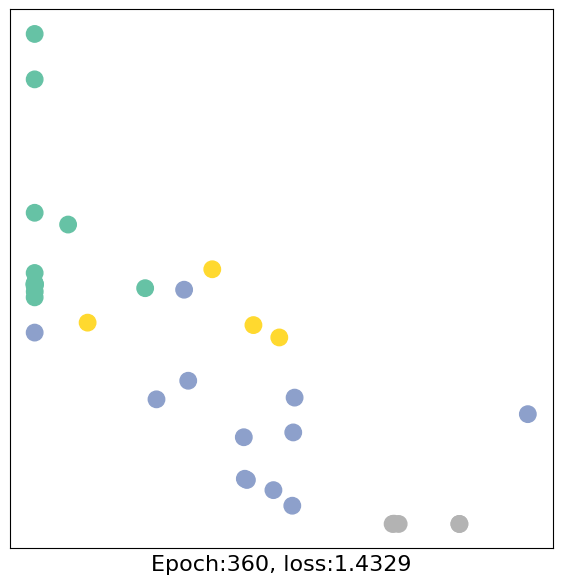

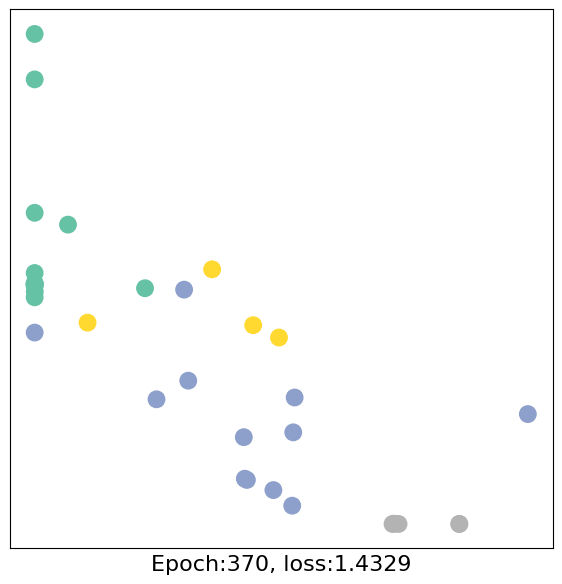

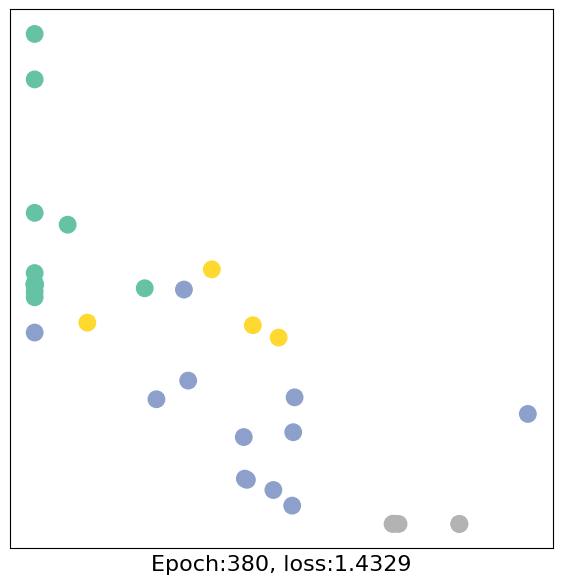

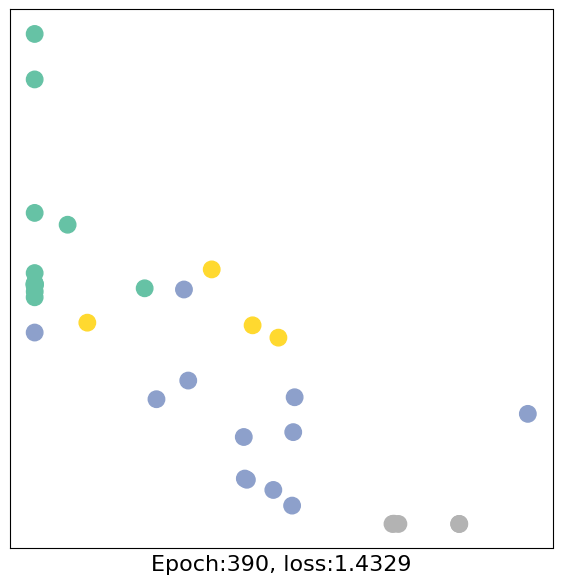

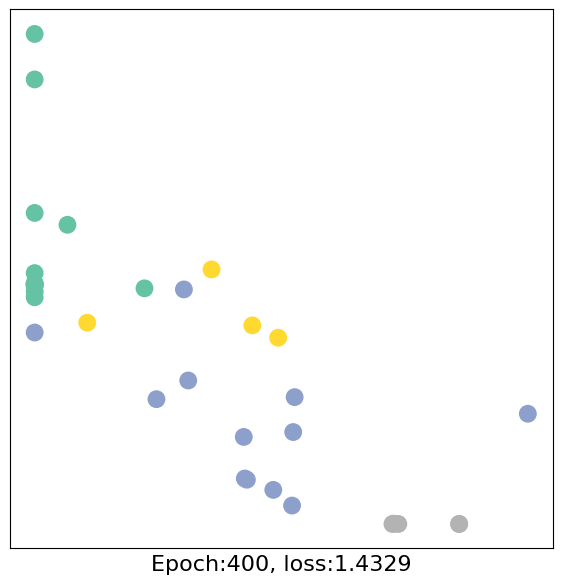

In [10]:
#traininggg
model =GCN()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
def train(data):
  optimizer.zero_grad()
  out,n = model(data.x,data.edge_index)
  loss=criterion(out[data.train_mask],data.y[data.train_mask])
  loss.backward()
  optimizer.step()
  return loss,n
#trainning loop

for epoch in range(401):
  Loss,n = train(data)
  if epoch % 10 == 0:
    visualize_embedding(n, color=data.y, epoch=epoch, loss=loss)